In [39]:
import pandas as pd
import statsmodels.formula.api as smf

# 1. データの読み込み
file_path = r"C:\Users\human1\OneDrive - 埼玉大学\共有ファイル\共同研究\松島さん\進捗報告\12.29\12.29\データセット\照明間瞳孔径データセット.csv"
df = pd.read_csv(file_path)

# 2. 変動効果（ランダム効果）の準備
# statsmodelsで複数の変動効果（subject, number, question）を同時に扱う場合、
# 全データを一つのグループ（group=1）とし、vc_formula（分散成分公式）を使用します。
df['group'] = 1

# 3. 混合効果モデルの定義
# 固定効果: brightness_con
# 変動効果: subject, number, question (それぞれをカテゴリカル変数として指定)
model = smf.mixedlm(
    # formula="ave_pupil_ave ~ brightness_con",
    formula="ave_pupil_ave_std ~ brightness_con", 
    data=df, 
    groups=df["group"],
    vc_formula={
        "subject": "0 + C(subject)",
        "number": "0 + C(number)",
        "question": "0 + C(question)"
    }
)

# 4. モデルの適合（計算実行）
result = model.fit()

# 5. 解析結果の表示
print("--- [1] 固定効果の結果 (全体の傾向) ---")
# 固定効果の係数、標準誤差、p値などが表示されます
print(result.summary().tables[1])

print("\n--- [2] 変動効果の分散成分 ---")
# 各要素（subject, number, question）がどれくらいバラついているかを示します
print(result.vcomp)

print("\n--- [3] 変動効果の個別の係数 (BLUPs) ---")
# 各被験者や各問題が、全体の平均からどれだけズレているかの予測値です
# result.random_effects は辞書形式で返されるため、グループ「1」の結果を取得します
random_effects = result.random_effects[1]
for key, value in random_effects.items():
    print(f"{key}: {value:.4f}")

# (補足) 特定の被験者に対する最終的な係数を知りたい場合
# 例: 被験者1の切片 = 固定効果の切片 + subject 1 のランダム効果
intercept_fixed = result.params['Intercept']
subject1_effect = random_effects['subject[C(subject)[1]]']
print(f"\n被験者1の独自の切片推定値: {intercept_fixed + subject1_effect:.4f}")

--- [1] 固定効果の結果 (全体の傾向) ---
                 Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept        1.727    0.238   7.264  0.000   1.261   2.193
brightness_con  -0.007    0.001  -9.434  0.000  -0.009  -0.006
number Var       0.000    0.083                               
question Var     0.012    0.110                               
subject Var      0.057    0.277                               

--- [2] 変動効果の分散成分 ---
[5.01597231e-10 1.19380892e-02 5.68884800e-02]

--- [3] 変動効果の個別の係数 (BLUPs) ---
number[C(number)[1]]: -0.0000
number[C(number)[2]]: -0.0000
number[C(number)[3]]: -0.0000
number[C(number)[4]]: 0.0000
number[C(number)[5]]: -0.0000
number[C(number)[6]]: 0.0000
question[C(question)[1]]: -0.0935
question[C(question)[2]]: -0.0128
question[C(question)[3]]: -0.0166
question[C(question)[4]]: 0.0362
question[C(question)[5]]: 0.0039
question[C(question)[6]]: 0.0828
subject[C(subject)[1]]: -0.1633
subject[C(subject)[2]]: -0.0780
subject[C(subject)[3]]: 0.2413

被験者1の独自の切片推定値: 1.

c:\Users\human1\je\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [40]:
# 1. データの読み込み
file_path = r"C:\Users\human1\OneDrive - 埼玉大学\共有ファイル\共同研究\松島さん\進捗報告\12.29\12.29\データセット\照明間瞳孔径データセット.csv"
df = pd.read_csv(file_path)

In [41]:
df["brightness_z"] = (df["brightness_con"] - df["brightness_con"].mean()) / df["brightness_con"].std()
df["number_z"] = (df["number"] - df["number"].mean()) / df["number"].std()


In [42]:
model = smf.mixedlm(
    # "ave_pupil_ave ~ brightness_z * number_z",
    "ave_pupil_ave_std ~ brightness_z * number_z",
    data=df,
    groups="subject",
    vc_formula={"question": "0 + C(question)"}
)

result = model.fit(method="lbfgs")
print(result.summary())


             Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: ave_pupil_ave_std
No. Observations:  18      Method:             REML             
No. Groups:        3       Scale:              0.0787           
Min. group size:   6       Log-Likelihood:     -12.0653         
Max. group size:   6       Converged:          Yes              
Mean group size:   6.0                                          
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              0.087    0.096  0.898 0.369 -0.102  0.275
brightness_z          -0.713    0.122 -5.843 0.000 -0.952 -0.474
number_z               0.039    0.125  0.314 0.754 -0.205  0.284
brightness_z:number_z -0.027    0.039 -0.691 0.490 -0.103  0.049
question Var           0.079                                    



c:\Users\human1\je\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [43]:
result.random_effects

{np.int64(1): question[C(question)[1]]   -0.307539
 question[C(question)[2]]   -0.027789
 question[C(question)[3]]    0.032911
 question[C(question)[4]]    0.014414
 question[C(question)[5]]   -0.060820
 question[C(question)[6]]   -0.273457
 dtype: float64,
 np.int64(2): question[C(question)[1]]   -0.143712
 question[C(question)[2]]   -0.145117
 question[C(question)[3]]   -0.213036
 question[C(question)[4]]    0.039649
 question[C(question)[5]]   -0.057089
 question[C(question)[6]]    0.251041
 dtype: float64,
 np.int64(3): question[C(question)[1]]   -0.026555
 question[C(question)[2]]    0.146489
 question[C(question)[3]]    0.122742
 question[C(question)[4]]    0.130749
 question[C(question)[5]]    0.130697
 question[C(question)[6]]    0.386421
 dtype: float64}

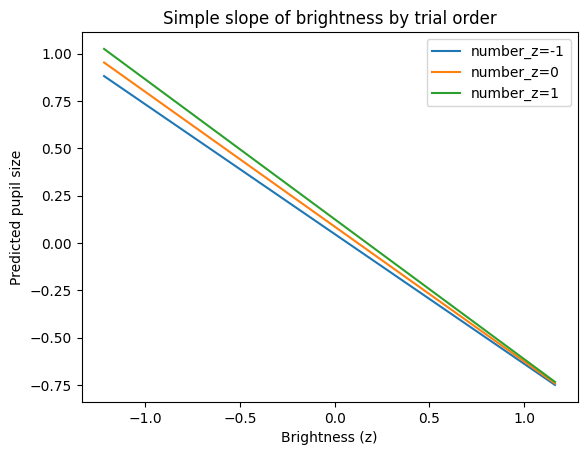

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# number の代表値
number_vals = [-1, 0, 1]

brightness_range = np.linspace(
    df["brightness_z"].min(),
    df["brightness_z"].max(),
    50
)

for n in number_vals:
    pred_df = pd.DataFrame({
        "brightness_z": brightness_range,
        "number_z": n,
        "subject": df["subject"].iloc[0],
        "question": df["question"].iloc[0]
    })
    y_pred = result.predict(pred_df)
    plt.plot(brightness_range, y_pred, label=f"number_z={n}")

plt.xlabel("Brightness (z)")
plt.ylabel("Predicted pupil size")
plt.legend()
plt.title("Simple slope of brightness by trial order")
plt.show()


In [45]:
model_cat = smf.mixedlm(
    # "ave_pupil_ave ~ C(brightness_con) + number_z",
    "ave_pupil_ave_std ~ C(brightness_con) + number_z",
    data=df,
    groups="subject",
    vc_formula={"question": "0 + C(question)"}
)
result_cat = model_cat.fit()
print(result_cat.summary())


                   Mixed Linear Model Regression Results
Model:                 MixedLM     Dependent Variable:     ave_pupil_ave_std
No. Observations:      18          Method:                 REML             
No. Groups:            3           Scale:                  0.0716           
Min. group size:       6           Log-Likelihood:         -10.1030         
Max. group size:       6           Converged:              Yes              
Mean group size:       6.0                                                  
----------------------------------------------------------------------------
                                 Coef.  Std.Err.    z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------
Intercept                         1.002    0.137   7.324 0.000  0.734  1.271
C(brightness_con)[T.230.4666667] -1.121    0.173  -6.486 0.000 -1.460 -0.782
C(brightness_con)[T.334.8]       -1.674    0.110 -15.212 0.000 -1.890 -1.459
number_z           

c:\Users\human1\je\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [46]:
import pymc as pm
import numpy as np

# インデックス化
subject_idx = df["subject"].astype("category").cat.codes.values
question_idx = df["question"].astype("category").cat.codes.values

n_subject = len(np.unique(subject_idx))
n_question = len(np.unique(question_idx))

brightness = df["brightness_z"].values
number = df["number_z"].values
# y = df["ave_pupil_ave"].values
y = df["ave_pupil_ave_std"].values

with pm.Model() as model:

    # 固定効果（弱情報事前分布）
    beta_0 = pm.Normal("beta_0", 0, 1)
    beta_brightness = pm.Normal("beta_brightness", 0, 1)
    beta_number = pm.Normal("beta_number", 0, 1)

    # ランダム効果の分散
    sigma_subject = pm.HalfNormal("sigma_subject", 1)
    sigma_question = pm.HalfNormal("sigma_question", 1)

    # ランダム効果（BLUP）
    subject_offset = pm.Normal("subject_offset", 0, 1, shape=n_subject)
    question_offset = pm.Normal("question_offset", 0, 1, shape=n_question)

    mu = (
        beta_0
        + beta_brightness * brightness
        + beta_number * number
        + subject_offset[subject_idx] * sigma_subject
        + question_offset[question_idx] * sigma_question
    )

    sigma = pm.HalfNormal("sigma", 1)

    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

    trace = pm.sample(2000, tune=2000, target_accept=0.9)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_0, beta_brightness, beta_number, sigma_subject, sigma_question, subject_offset, question_offset, sigma]


c:\Users\human1\je\.venv\Lib\site-packages\rich\live.py:256: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 803 seconds.
There were 13 divergences after tuning. Increase `target_accept` or reparameterize.


In [47]:
trace.posterior["question_offset"]

<xarray.DataArray 'question_offset' (chain: 4, draw: 2000,
                                     question_offset_dim_0: 6)> Size: 384kB
array([[[-0.95230332,  0.62296168,  0.82455956, -0.33975186,
          0.31847225,  0.37067172],
        [-0.77461585, -0.28781623,  0.32329121,  0.35307231,
          0.03988003,  1.27385875],
        [-0.31942728,  0.03992679,  0.08684963,  0.4552879 ,
          0.22049122,  0.72283438],
        ...,
        [-0.1372419 ,  0.44352712,  0.60576907,  1.47017006,
          1.09810958,  1.04373936],
        [-0.21500164,  0.16401648, -0.28037927,  0.01294376,
         -1.07782991, -0.79149945],
        [-0.77742851, -0.63802418,  1.3129166 , -0.32744314,
         -0.20249527,  1.27755041]],

       [[-0.23044202, -1.86728497,  0.00669191, -0.39733573,
         -0.21049672,  0.26834133],
        [ 0.46308861, -1.5214287 ,  0.61021726,  0.36753751,
         -0.62828829,  0.35236191],
        [ 0.26095171, -1.14031115, -0.20026601, -0.06256856,
         -0.06060801,  0.73594717],
...
        [-0.79171323,  1.02661267, -0.27191263,  0.19087818,
         -0.53108103,  1.1193067 ],
        [-0.35589652,  0.22141001,  0.13479935,  0.39358419,
         -0.1483444 , -0.11824105],
        [-1.60259387, -0.79404194, -0.7475923 , -1.01512255,
         -0.31490378,  0.73155827]],

       [[ 0.43925106,  0.91661674, -0.71280402,  1.72876708,
          0.53219255,  0.63525278],
        [-0.48751649, -1.07319565, -0.65632822, -0.55594598,
          0.56923446, -0.75797697],
        [ 0.85478753,  0.23275218, -0.16730532,  1.12458676,
          0.45338896,  0.93480059],
        ...,
        [-0.91399691, -0.95511476,  0.10339191, -0.13760443,
         -0.2698397 , -0.80696455],
        [-1.23910671, -0.12985522, -0.33759381, -0.15612163,
          0.00498483, -0.0866029 ],
        [-1.4531431 , -1.22337711, -0.48243315,  0.36745196,
         -1.12299965, -0.18772476]]], shape=(4, 2000, 6))
Coordinates:
  * chain                  (chain) int64 32B 0 1 2 3
  * draw                   (draw) int64 16kB 0 1 2 3 4 ... 1996 1997 1998 1999
  * question_offset_dim_0  (question_offset_dim_0) int64 48B 0 1 2 3 4 5

In [48]:
import numpy as np
import pandas as pd

# question_offset: (chain, draw, question)
q_samples = trace.posterior["question_offset"].values.reshape(-1, n_question)

summary = pd.DataFrame({
    "question": [f"Q{i+1}" for i in range(n_question)],
    "mean": q_samples.mean(axis=0),
    "lower": np.percentile(q_samples, 2.5, axis=0),
    "upper": np.percentile(q_samples, 97.5, axis=0)
})


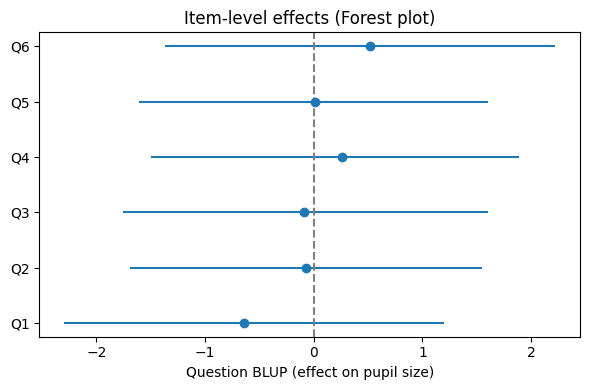

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
y_pos = range(len(summary))

plt.errorbar(
    summary["mean"],
    y_pos,
    xerr=[
        summary["mean"] - summary["lower"],
        summary["upper"] - summary["mean"]
    ],
    fmt="o"
)

plt.axvline(0, linestyle="--", color="gray")
plt.yticks(y_pos, summary["question"])
plt.xlabel("Question BLUP (effect on pupil size)")
plt.title("Item-level effects (Forest plot)")
plt.tight_layout()
plt.show()


In [50]:
b_samples = trace.posterior["beta_brightness"].values.flatten()

brightness_summary = {
    "mean": b_samples.mean(),
    "lower": np.percentile(b_samples, 2.5),
    "upper": np.percentile(b_samples, 97.5)
}


In [51]:
combined = pd.concat([
    summary.assign(type="Question"),
    pd.DataFrame({
        "question": ["Brightness"],
        "mean": [brightness_summary["mean"]],
        "lower": [brightness_summary["lower"]],
        "upper": [brightness_summary["upper"]],
        "type": ["Brightness"]
    })
])


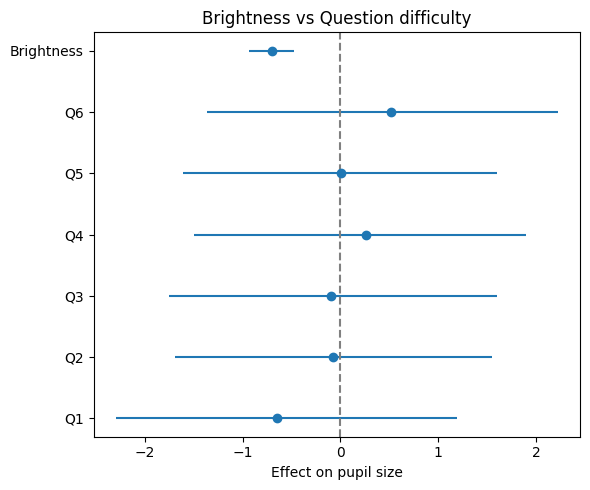

In [52]:
plt.figure(figsize=(6, 5))
y_pos = range(len(combined))

plt.errorbar(
    combined["mean"],
    y_pos,
    xerr=[
        combined["mean"] - combined["lower"],
        combined["upper"] - combined["mean"]
    ],
    fmt="o"
)

plt.axvline(0, linestyle="--", color="gray")
plt.yticks(y_pos, combined["question"])
plt.xlabel("Effect on pupil size")
plt.title("Brightness vs Question difficulty")
plt.tight_layout()
plt.show()


In [53]:
import arviz as az

# 主要なパラメータ（固定効果と各グループの分散）を指定
var_names = ["beta_0", "beta_brightness", "beta_number", "sigma_subject", "sigma_question", "sigma"]

# 要約統計量の表示 (95% HDIを指定)
summary = az.summary(trace, var_names=var_names, hdi_prob=0.95)
print(summary)

                  mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  \
beta_0           0.053  0.289    -0.621      0.593      0.006    0.007   
beta_brightness -0.703  0.116    -0.933     -0.475      0.002    0.002   
beta_number      0.022  0.119    -0.212      0.260      0.002    0.002   
sigma_subject    0.428  0.332     0.000      1.071      0.007    0.011   
sigma_question   0.182  0.148     0.000      0.464      0.003    0.003   
sigma            0.344  0.086     0.200      0.514      0.002    0.001   

                 ess_bulk  ess_tail  r_hat  
beta_0             2678.0    2037.0    1.0  
beta_brightness    4974.0    4935.0    1.0  
beta_number        4767.0    4544.0    1.0  
sigma_subject      1708.0    1919.0    1.0  
sigma_question     2514.0    3005.0    1.0  
sigma              3131.0    4553.0    1.0  


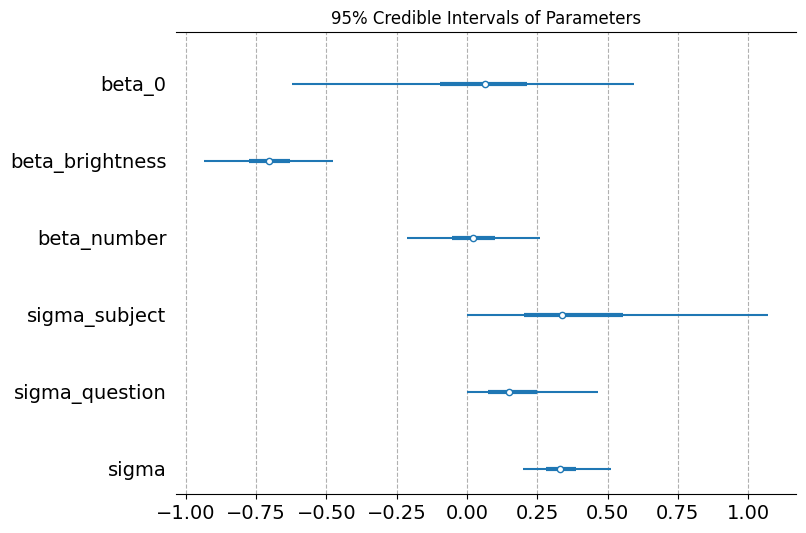

In [54]:
import matplotlib.pyplot as plt

# フォレストプロットの描画
# combined=True は複数のチェーンをまとめて表示する設定です
az.plot_forest(trace, var_names=var_names, combined=True, hdi_prob=0.95, figsize=(8, 6))

plt.title("95% Credible Intervals of Parameters")
plt.grid(True, axis='x', linestyle='--')
plt.show()

Text(0.5, 1.0, 'Estimated parameters for pupil size')

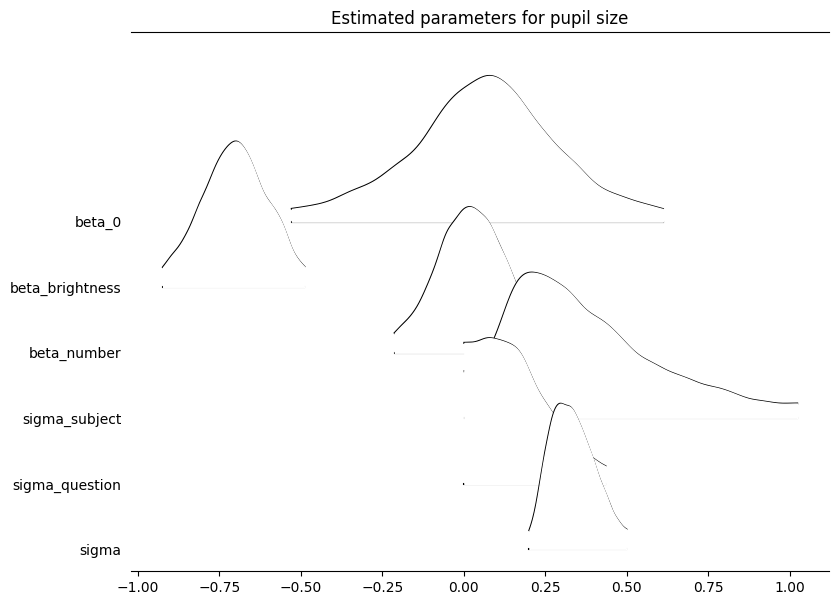

In [57]:
axes = az.plot_forest(trace,
                           kind='ridgeplot',
                           var_names=var_names,
                           combined=True,
                           ridgeplot_overlap=3,
                           colors='white',
                           figsize=(9, 7))
axes[0].set_title('Estimated parameters for pupil size')

Text(0.5, 1.0, 'Estimated parameters for pupil size')

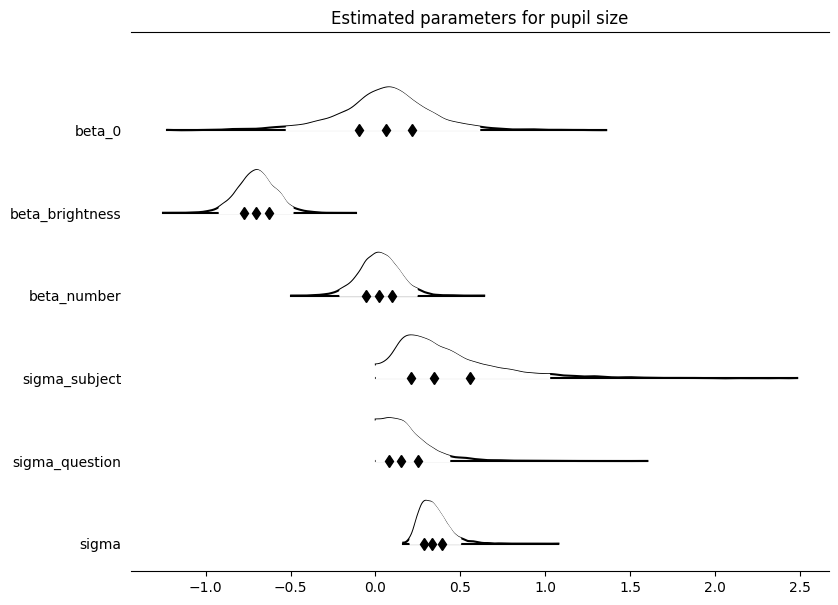

In [58]:
axes = az.plot_forest(trace,
                           kind='ridgeplot',
                           var_names=var_names,
                           combined=True,
                           ridgeplot_truncate=False,
                           ridgeplot_quantiles=[.25, .5, .75],
                           ridgeplot_overlap=0.7,
                           colors='white',
                           figsize=(9, 7))
axes[0].set_title('Estimated parameters for pupil size')

In [59]:
# ============================================
# 感度分析（Sensitivity Analysis）
# ============================================
# 事前分布のハイパーパラメータを変更して、事後分布への影響を確認

import arviz as az
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

# データの準備（Cell 7と同じ）
subject_idx = df["subject"].astype("category").cat.codes.values
question_idx = df["question"].astype("category").cat.codes.values
n_subject = len(np.unique(subject_idx))
n_question = len(np.unique(question_idx))
brightness = df["brightness_z"].values
number = df["number_z"].values
y = df["ave_pupil_ave_std"].values

# 事前分布の設定（弱い、中程度、強い）
prior_configs = {
    "弱い事前分布": {
        "beta_sd": 10.0,      # 固定効果の標準偏差（大きい = 弱い情報）
        "sigma_scale": 10.0,  # 分散パラメータのスケール（大きい = 弱い情報）
        "offset_sd": 10.0     # ランダム効果の標準偏差
    },
    "中程度の事前分布（デフォルト）": {
        "beta_sd": 1.0,
        "sigma_scale": 1.0,
        "offset_sd": 1.0
    },
    "強い事前分布": {
        "beta_sd": 0.1,       # 固定効果の標準偏差（小さい = 強い情報）
        "sigma_scale": 0.1,   # 分散パラメータのスケール（小さい = 強い情報）
        "offset_sd": 0.1      # ランダム効果の標準偏差
    }
}

print("感度分析を開始します...")
print("=" * 60)


感度分析を開始します...


In [60]:
# 各事前分布設定でモデルを実行
traces = {}
summaries = {}

for config_name, config in prior_configs.items():
    print(f"\n[{config_name}] モデルを実行中...")
    print(f"  設定: beta_sd={config['beta_sd']}, sigma_scale={config['sigma_scale']}, offset_sd={config['offset_sd']}")
    
    with pm.Model() as model_sens:
        # 固定効果（事前分布の強さを変更）
        beta_0 = pm.Normal("beta_0", 0, config["beta_sd"])
        beta_brightness = pm.Normal("beta_brightness", 0, config["beta_sd"])
        beta_number = pm.Normal("beta_number", 0, config["beta_sd"])

        # ランダム効果の分散（事前分布の強さを変更）
        sigma_subject = pm.HalfNormal("sigma_subject", config["sigma_scale"])
        sigma_question = pm.HalfNormal("sigma_question", config["sigma_scale"])

        # ランダム効果（BLUP）（事前分布の強さを変更）
        subject_offset = pm.Normal("subject_offset", 0, config["offset_sd"], shape=n_subject)
        question_offset = pm.Normal("question_offset", 0, config["offset_sd"], shape=n_question)

        mu = (
            beta_0
            + beta_brightness * brightness
            + beta_number * number
            + subject_offset[subject_idx] * sigma_subject
            + question_offset[question_idx] * sigma_question
        )

        sigma = pm.HalfNormal("sigma", config["sigma_scale"])
        y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

        # サンプリング（感度分析のため、少し少なめのサンプル数で実行）
        trace_sens = pm.sample(1000, tune=1000, target_accept=0.9, return_inferencedata=True)
    
    traces[config_name] = trace_sens
    
    # 要約統計量を保存
    var_names = ["beta_0", "beta_brightness", "beta_number", "sigma_subject", "sigma_question", "sigma"]
    summaries[config_name] = az.summary(trace_sens, var_names=var_names, hdi_prob=0.95)
    
    print(f"  ✓ 完了")

print("\n" + "=" * 60)
print("すべてのモデル実行が完了しました。")



[弱い事前分布] モデルを実行中...
  設定: beta_sd=10.0, sigma_scale=10.0, offset_sd=10.0


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_0, beta_brightness, beta_number, sigma_subject, sigma_question, subject_offset, question_offset, sigma]


c:\Users\human1\je\.venv\Lib\site-packages\rich\live.py:256: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1306 seconds.
There were 345 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


  ✓ 完了

[中程度の事前分布（デフォルト）] モデルを実行中...
  設定: beta_sd=1.0, sigma_scale=1.0, offset_sd=1.0


...

  ✓ 完了

[強い事前分布] モデルを実行中...
  設定: beta_sd=0.1, sigma_scale=0.1, offset_sd=0.1


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_0, beta_brightness, beta_number, sigma_subject, sigma_question, subject_offset, question_offset, sigma]


c:\Users\human1\je\.venv\Lib\site-packages\rich\live.py:256: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 289 seconds.


  ✓ 完了

すべてのモデル実行が完了しました。


In [61]:
# ============================================
# 感度分析結果の比較：要約統計量
# ============================================

print("\n【感度分析結果：主要パラメータの比較】\n")
print("=" * 80)

# 主要パラメータを比較
key_params = ["beta_brightness", "beta_0", "sigma_subject", "sigma_question"]

for param in key_params:
    print(f"\n【{param}】")
    print("-" * 80)
    for config_name in prior_configs.keys():
        if param in summaries[config_name].index:
            row = summaries[config_name].loc[param]
            print(f"{config_name:30s} | 平均: {row['mean']:8.4f} | "
                  f"95%HDI: [{row['hdi_2.5%']:8.4f}, {row['hdi_97.5%']:8.4f}]")
    print()



【感度分析結果：主要パラメータの比較】


【beta_brightness】
--------------------------------------------------------------------------------
弱い事前分布                         | 平均:  -0.7000 | 95%HDI: [ -0.9220,  -0.4820]
中程度の事前分布（デフォルト）                | 平均:  -0.7000 | 95%HDI: [ -0.9150,  -0.4780]
強い事前分布                         | 平均:  -0.3520 | 95%HDI: [ -0.5160,  -0.2050]


【beta_0】
--------------------------------------------------------------------------------
弱い事前分布                         | 平均:  -0.1400 | 95%HDI: [ -1.4940,   0.7070]
中程度の事前分布（デフォルト）                | 平均:   0.0710 | 95%HDI: [ -0.5350,   0.6180]
強い事前分布                         | 平均:   0.0420 | 95%HDI: [ -0.0920,   0.1740]


【sigma_subject】
--------------------------------------------------------------------------------
弱い事前分布                         | 平均:   0.1160 | 95%HDI: [  0.0040,   0.4320]
中程度の事前分布（デフォルト）                | 平均:   0.4250 | 95%HDI: [  0.0000,   1.0370]
強い事前分布                         | 平均:   0.0820 | 95%HDI: [  0.0000,   0.

C:\Users\human1\AppData\Local\Temp\ipykernel_6512\1333482246.py:26: UserWarning: Glyph 23494 (\N{CJK UNIFIED IDEOGRAPH-5BC6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\human1\AppData\Local\Temp\ipykernel_6512\1333482246.py:26: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\human1\AppData\Local\Temp\ipykernel_6512\1333482246.py:26: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\human1\AppData\Local\Temp\ipykernel_6512\1333482246.py:26: UserWarning: Glyph 20107 (\N{CJK UNIFIED IDEOGRAPH-4E8B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\human1\AppData\Local\Temp\ipykernel_6512\1333482246.py:26: UserWarning: Glyph 24460 (\N{CJK UNIFIED IDEOGRAPH-5F8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\human1\AppData\Local\Temp\ipykernel_6512\1333482246.py:26: UserWarning: Glyph 20998 (\N{CJK UN

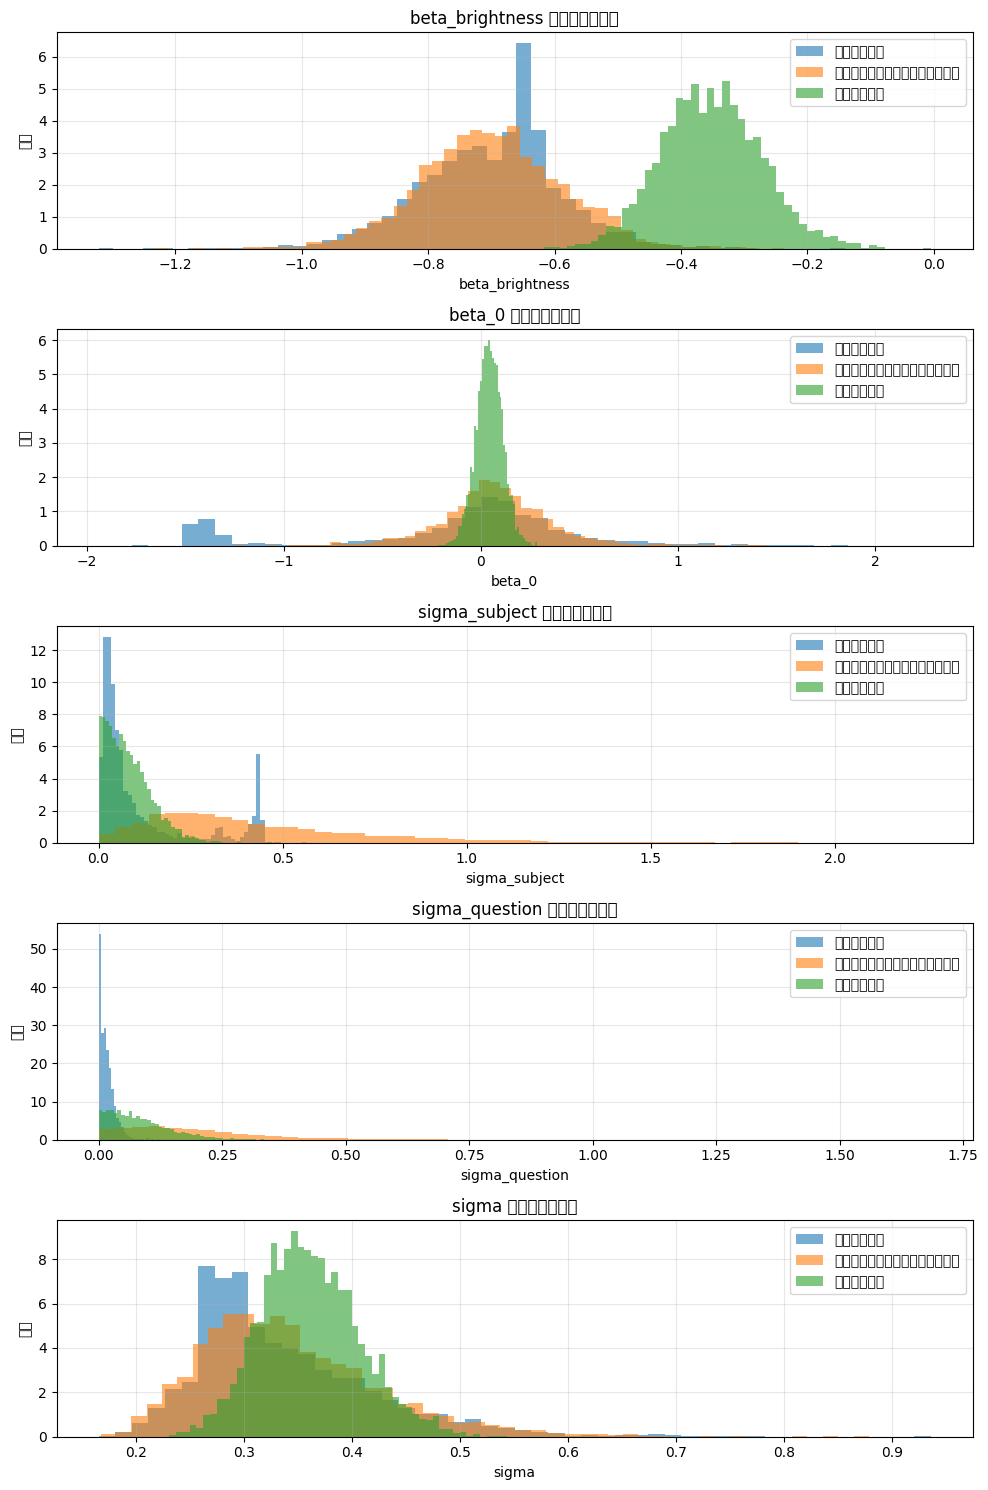

In [62]:
# ============================================
# 感度分析結果の可視化：事後分布の比較
# ============================================

# 主要パラメータの事後分布を比較
key_params = ["beta_brightness", "beta_0", "sigma_subject", "sigma_question", "sigma"]

fig, axes = plt.subplots(len(key_params), 1, figsize=(10, 3*len(key_params)))
if len(key_params) == 1:
    axes = [axes]

for idx, param in enumerate(key_params):
    ax = axes[idx]
    
    for config_name, trace_sens in traces.items():
        if param in trace_sens.posterior:
            samples = trace_sens.posterior[param].values.flatten()
            ax.hist(samples, bins=50, alpha=0.6, label=config_name, density=True)
    
    ax.set_xlabel(param)
    ax.set_ylabel("密度")
    ax.set_title(f"{param} の事後分布比較")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


C:\Users\human1\AppData\Local\Temp\ipykernel_6512\1965606491.py:55: UserWarning: Glyph 12497 (\N{KATAKANA LETTER PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\human1\AppData\Local\Temp\ipykernel_6512\1965606491.py:55: UserWarning: Glyph 12521 (\N{KATAKANA LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\human1\AppData\Local\Temp\ipykernel_6512\1965606491.py:55: UserWarning: Glyph 12513 (\N{KATAKANA LETTER ME}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\human1\AppData\Local\Temp\ipykernel_6512\1965606491.py:55: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\human1\AppData\Local\Temp\ipykernel_6512\1965606491.py:55: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\human1\AppData\Local\Temp\ipykernel_6512\1965606491.py:55: UserWarning: Glyph 20516 (\N{CJK UNIFIED IDEOGR

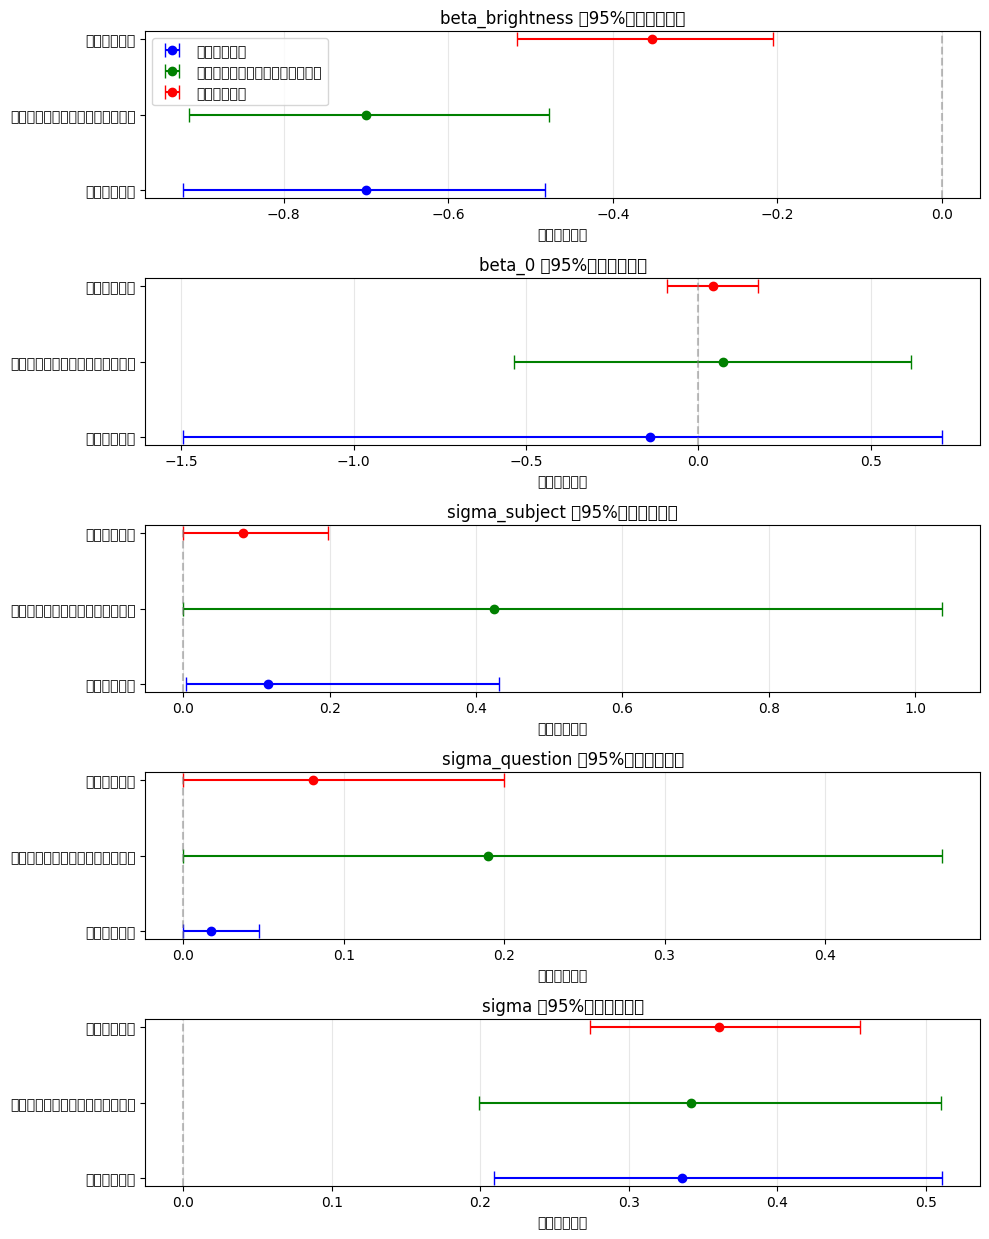

In [63]:
# ============================================
# 感度分析結果の可視化：95%信頼区間の比較（フォレストプロット）
# ============================================

# 各パラメータの95%HDIを比較
comparison_data = []

for config_name in prior_configs.keys():
    for param in key_params:
        if param in summaries[config_name].index:
            row = summaries[config_name].loc[param]
            comparison_data.append({
                "設定": config_name,
                "パラメータ": param,
                "平均": row['mean'],
                "下限": row['hdi_2.5%'],
                "上限": row['hdi_97.5%']
            })

comparison_df = pd.DataFrame(comparison_data)

# パラメータごとにプロット
fig, axes = plt.subplots(len(key_params), 1, figsize=(10, 2.5*len(key_params)))
if len(key_params) == 1:
    axes = [axes]

for idx, param in enumerate(key_params):
    ax = axes[idx]
    param_data = comparison_df[comparison_df["パラメータ"] == param]
    
    y_positions = range(len(param_data))
    colors = ['blue', 'green', 'red']
    
    for i, (_, row) in enumerate(param_data.iterrows()):
        config_idx = list(prior_configs.keys()).index(row["設定"])
        ax.errorbar(
            row["平均"],
            i,
            xerr=[[row["平均"] - row["下限"]], [row["上限"] - row["平均"]]],
            fmt='o',
            capsize=5,
            label=row["設定"] if idx == 0 else "",
            color=colors[config_idx]
        )
    
    ax.set_yticks(y_positions)
    ax.set_yticklabels(param_data["設定"].values)
    ax.set_xlabel("パラメータ値")
    ax.set_title(f"{param} の95%信頼区間比較")
    ax.axvline(0, linestyle='--', color='gray', alpha=0.5)
    ax.grid(True, alpha=0.3, axis='x')
    if idx == 0:
        ax.legend()

plt.tight_layout()
plt.show()


In [64]:
# ============================================
# 感度分析の要約：パラメータの変動範囲
# ============================================

print("\n【感度分析の要約】")
print("=" * 80)
print("\n各パラメータの事後分布が事前分布の設定によってどの程度変化するかを確認しました。\n")

# 各パラメータの変動範囲を計算
for param in key_params:
    means = []
    hdi_lowers = []
    hdi_uppers = []
    
    for config_name in prior_configs.keys():
        if param in summaries[config_name].index:
            row = summaries[config_name].loc[param]
            means.append(row['mean'])
            hdi_lowers.append(row['hdi_2.5%'])
            hdi_uppers.append(row['hdi_97.5%'])
    
    if means:
        mean_range = max(means) - min(means)
        hdi_range = max(hdi_uppers) - min(hdi_lowers)
        
        print(f"{param}:")
        print(f"  平均値の範囲: {min(means):.4f} ～ {max(means):.4f} (範囲: {mean_range:.4f})")
        print(f"  95%HDIの範囲: {min(hdi_lowers):.4f} ～ {max(hdi_uppers):.4f} (範囲: {hdi_range:.4f})")
        
        # 感度の評価
        if mean_range < 0.01:
            sensitivity = "低い（頑健）"
        elif mean_range < 0.1:
            sensitivity = "中程度"
        else:
            sensitivity = "高い（注意が必要）"
        
        print(f"  感度評価: {sensitivity}\n")

print("\n【解釈】")
print("-" * 80)
print("・感度が低い（頑健）: 事前分布の設定が変わっても結果が大きく変わらない")
print("・感度が高い: 事前分布の設定によって結果が大きく変わる可能性がある")
print("   → より慎重な事前分布の選択や、追加のデータ収集を検討")
print("=" * 80)



【感度分析の要約】

各パラメータの事後分布が事前分布の設定によってどの程度変化するかを確認しました。

beta_brightness:
  平均値の範囲: -0.7000 ～ -0.3520 (範囲: 0.3480)
  95%HDIの範囲: -0.9220 ～ -0.2050 (範囲: 0.7170)
  感度評価: 高い（注意が必要）

beta_0:
  平均値の範囲: -0.1400 ～ 0.0710 (範囲: 0.2110)
  95%HDIの範囲: -1.4940 ～ 0.7070 (範囲: 2.2010)
  感度評価: 高い（注意が必要）

sigma_subject:
  平均値の範囲: 0.0820 ～ 0.4250 (範囲: 0.3430)
  95%HDIの範囲: 0.0000 ～ 1.0370 (範囲: 1.0370)
  感度評価: 高い（注意が必要）

sigma_question:
  平均値の範囲: 0.0170 ～ 0.1900 (範囲: 0.1730)
  95%HDIの範囲: 0.0000 ～ 0.4730 (範囲: 0.4730)
  感度評価: 高い（注意が必要）

sigma:
  平均値の範囲: 0.3360 ～ 0.3610 (範囲: 0.0250)
  95%HDIの範囲: 0.1990 ～ 0.5110 (範囲: 0.3120)
  感度評価: 中程度


【解釈】
--------------------------------------------------------------------------------
・感度が低い（頑健）: 事前分布の設定が変わっても結果が大きく変わらない
・感度が高い: 事前分布の設定によって結果が大きく変わる可能性がある
   → より慎重な事前分布の選択や、追加のデータ収集を検討


C:\Users\human1\AppData\Local\Temp\ipykernel_6512\1054215901.py:28: UserWarning: Glyph 23494 (\N{CJK UNIFIED IDEOGRAPH-5BC6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\human1\AppData\Local\Temp\ipykernel_6512\1054215901.py:28: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\human1\AppData\Local\Temp\ipykernel_6512\1054215901.py:28: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\human1\AppData\Local\Temp\ipykernel_6512\1054215901.py:28: UserWarning: Glyph 20107 (\N{CJK UNIFIED IDEOGRAPH-4E8B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\human1\AppData\Local\Temp\ipykernel_6512\1054215901.py:28: UserWarning: Glyph 24460 (\N{CJK UNIFIED IDEOGRAPH-5F8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\human1\AppData\Local\Temp\ipykernel_6512\1054215901.py:28: UserWarning: Glyph 20998 (\N{CJK UN

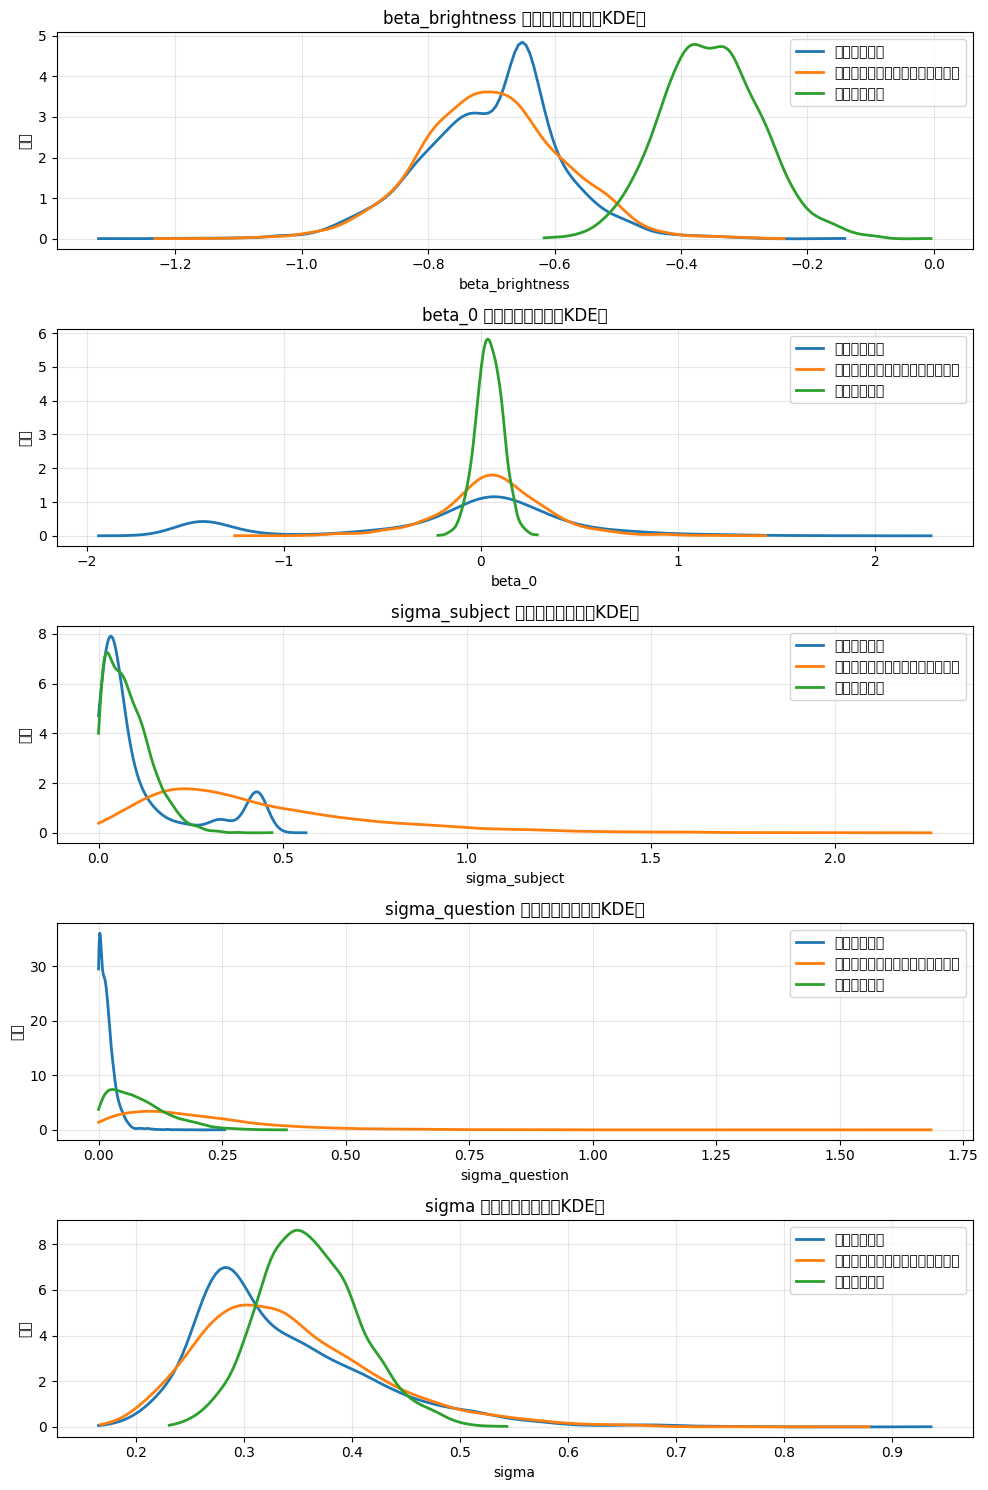

In [65]:
# ============================================
# 感度分析結果の可視化：KDEプロット（より滑らかな分布）
# ============================================

from scipy import stats

fig, axes = plt.subplots(len(key_params), 1, figsize=(10, 3*len(key_params)))
if len(key_params) == 1:
    axes = [axes]

for idx, param in enumerate(key_params):
    ax = axes[idx]
    
    for config_name, trace_sens in traces.items():
        if param in trace_sens.posterior:
            samples = trace_sens.posterior[param].values.flatten()
            # KDEプロット
            kde = stats.gaussian_kde(samples)
            x_range = np.linspace(samples.min(), samples.max(), 200)
            ax.plot(x_range, kde(x_range), label=config_name, linewidth=2)
    
    ax.set_xlabel(param)
    ax.set_ylabel("密度")
    ax.set_title(f"{param} の事後分布比較（KDE）")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
